In [33]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv(r"C:\Netflix-Data-Analysis\data\mymoviedb.csv", lineterminator='\n')

Note: lineterminator="\n" is used because the dataset caused a parsing error with the default settings. It specifies the end of each row and allows pandas to read the file correctly.

In [35]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


Checking the data type, null values, missing values, etc.

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [37]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [38]:
print(df.duplicated().sum())

0


In [39]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


### Exploration Summary

- The dataset contains **9,827 rows** and **9 columns**.
- The dataset is clean, with **no missing (NaN) values** or **duplicate records**.
- The `Release_Date` column will be converted to the **datetime** format, and the **year** will be extracted for analysis.
- The `Overview`, `Original_Language`, and `Poster_Url` columns are not required for this analysis and will be dropped.
- The `Popularity` column contains noticeable outliers that will be considered during the analysis.
- The `Vote_Average` column will be categorized to enable more meaningful analysis.
- The `Genre` column contains comma-separated values and extra whitespace, which will be cleaned before analysis.

In [40]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])

print(df['Release_Date'].dtype)

datetime64[ns]


In [41]:
df['Release_Date'] = df['Release_Date'].dt.year

print(df['Release_Date'].dtype)

int32


### Dropping the Columns 

In [42]:
cols = ['Overview','Original_Language','Poster_Url']

df.drop(cols, axis = 1, inplace = True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [43]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


### Categorizing the `Vote_Average` Column

We have to cut the `Vote_Average` values and make 4 categories : `popular` `average` `below_average` `not_popular` to describe it more using 'categorize_col()' function provided above . 

In [44]:
def categorize_col(df , col , labels ) :
    
    edges = [df[col].describe()['min'] , 
    df[col].describe()['25%'] , 
    df[col].describe()['50%'] ,
    df[col].describe()['75%'] , 
    df[col].describe()['max']]
    
    df[col + '_Category'] = pd.cut(df[col] , edges , labels = labels , duplicates = 'drop')
    
    return df

In [45]:
labels = ["not popular" , "below average" , "average" , "popular"]

categorize_col(df , 'Vote_Average' , labels)

df['Vote_Average_Category'].unique()

['popular', 'below average', 'average', 'not popular', NaN]
Categories (4, object): ['not popular' < 'below average' < 'average' < 'popular']

In [46]:
df['Vote_Average'].dtype
print(df['Vote_Average_Category'].describe())

count            9727
unique              4
top       not popular
freq             2467
Name: Vote_Average_Category, dtype: object


In [47]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",popular
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",popular
2,2022,No Exit,2618.087,122,6.3,Thriller,below average
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",popular
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",average


In [48]:
df["Vote_Average_Category"].value_counts()

Vote_Average_Category
not popular      2467
popular          2450
average          2412
below average    2398
Name: count, dtype: int64

* Dropping NaN and duplicate values 

In [49]:
df.dropna(inplace = True)

df.isna().sum()

Release_Date             0
Title                    0
Popularity               0
Vote_Count               0
Vote_Average             0
Genre                    0
Vote_Average_Category    0
dtype: int64

In [50]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",popular
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",popular
2,2022,No Exit,2618.087,122,6.3,Thriller,below average
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",popular
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",average


We'll split the `Genre` column into a list and use the `explode()` function to transform the dataset so that each movie has only one genre per row.

In [51]:
df['Genre'] = df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index(drop = True)

Casting Column into category

In [52]:
df['Genre'] = df['Genre'].astype('category')

df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [53]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Science Fiction,popular
3,2022,The Batman,3827.658,1151,8.1,Crime,popular
4,2022,The Batman,3827.658,1151,8.1,Mystery,popular


In [54]:
df.nunique()

Release_Date              100
Title                    9415
Popularity               8088
Vote_Count               3265
Vote_Average               73
Genre                      19
Vote_Average_Category       4
dtype: int64

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Release_Date           25552 non-null  int32   
 1   Title                  25552 non-null  object  
 2   Popularity             25552 non-null  float64 
 3   Vote_Count             25552 non-null  int64   
 4   Vote_Average           25552 non-null  float64 
 5   Genre                  25552 non-null  category
 6   Vote_Average_Category  25552 non-null  category
dtypes: category(2), float64(2), int32(1), int64(1), object(1)
memory usage: 949.2+ KB


In [56]:
df.nunique()

Release_Date              100
Title                    9415
Popularity               8088
Vote_Count               3265
Vote_Average               73
Genre                      19
Vote_Average_Category       4
dtype: int64

# Data Visualization

## Q.-1. What is the most frequent movie genre on Netflix ?

In [57]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

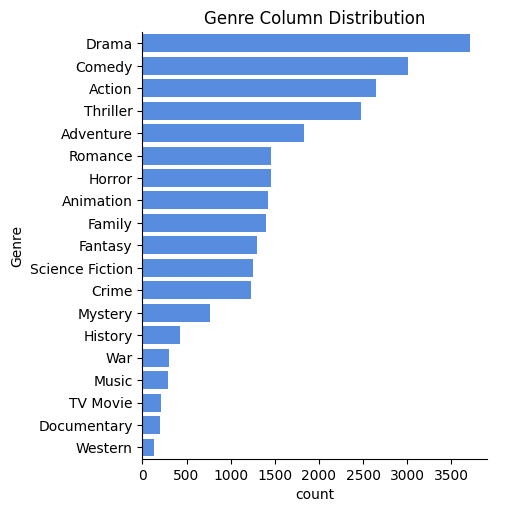

In [58]:
sns.catplot(y = 'Genre' , data = df , kind = 'count', 
            order = df['Genre'].value_counts().index,
            color = '#4287f5')

plt.title('Genre Column Distribution')
plt.show()

## Q.-2. How are movies distributed across different vote average categories?

In [59]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Science Fiction,popular
3,2022,The Batman,3827.658,1151,8.1,Crime,popular
4,2022,The Batman,3827.658,1151,8.1,Mystery,popular


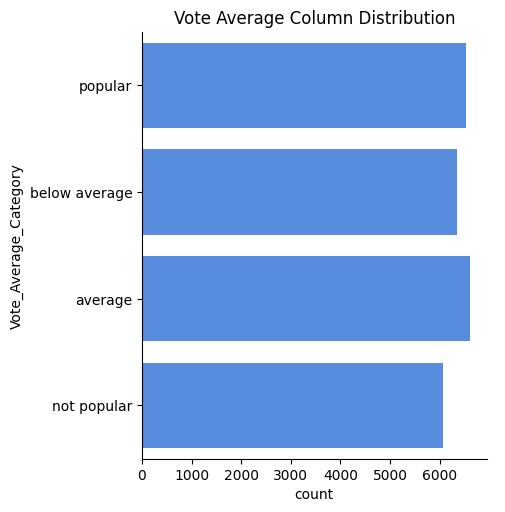

In [60]:
sns.catplot(y = 'Vote_Average_Category' , data = df , kind = 'count',
            order = df['Vote_Average_Category'] , 
            color = '#4287f5')

plt.title('Vote Average Column Distribution')
plt.show()

## Q.-3. Which genres have the highest average votes?

In [61]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Science Fiction,popular
3,2022,The Batman,3827.658,1151,8.1,Crime,popular
4,2022,The Batman,3827.658,1151,8.1,Mystery,popular


C:\Users\lapmall\AppData\Local\Temp\ipykernel_10300\2438729517.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Genre')['Vote_Average']


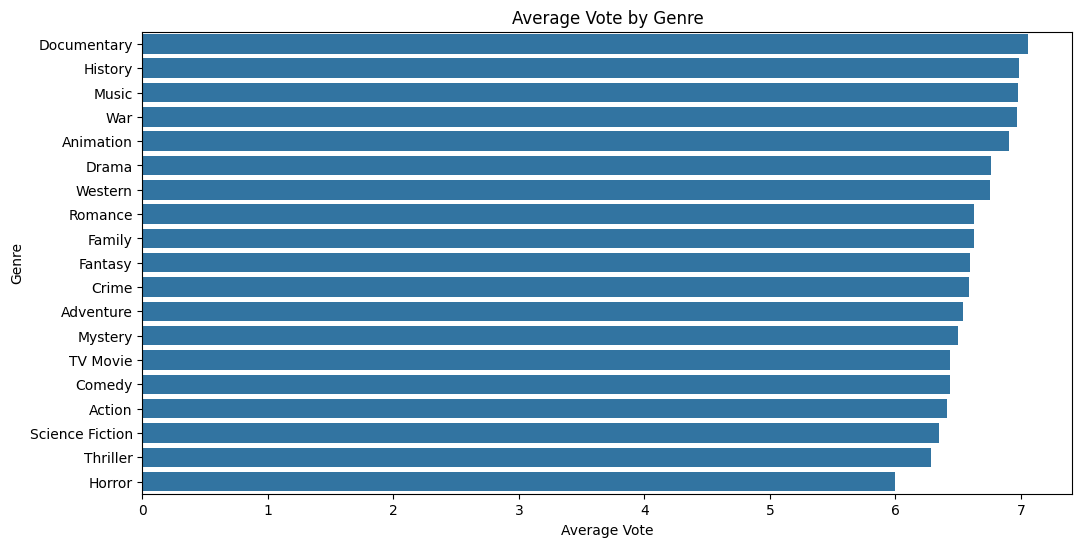

In [66]:
genre_votes = (
    df.groupby('Genre')['Vote_Average']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_votes.values,
    y=genre_votes.index,
    order=genre_votes.index
)

plt.title('Average Vote by Genre')
plt.xlabel('Average Vote')
plt.ylabel('Genre')

plt.show()

## Q.-4. Which movie has the highest popularity, and what is its genre?

In [63]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Action,popular
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Adventure,popular
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,Science Fiction,popular


## Q.-5. Which movie has the lowest popularity, and what is its genre?

In [64]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Category
25546,2021,The United States vs. Billie Holiday,13.354,152,6.7,Music,average
25547,2021,The United States vs. Billie Holiday,13.354,152,6.7,Drama,average
25548,2021,The United States vs. Billie Holiday,13.354,152,6.7,History,average
25549,1984,Threads,13.354,186,7.8,War,popular
25550,1984,Threads,13.354,186,7.8,Drama,popular
25551,1984,Threads,13.354,186,7.8,Science Fiction,popular


## Q.-6. Which release year has the highest number of movies?

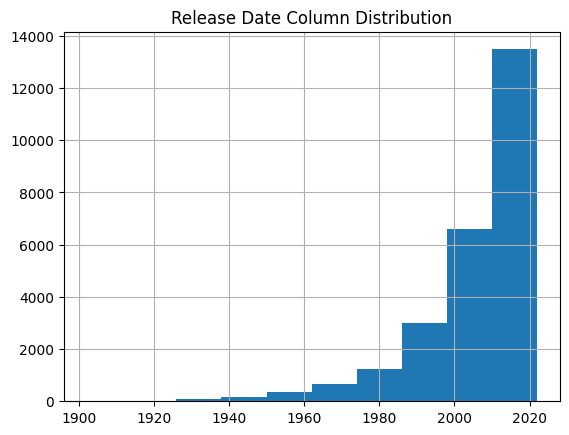

In [65]:
df['Release_Date'].hist()
plt.title('Release Date Column Distribution')
plt.show()